# Defining time-dependent incidence hazard of MCI due to AD

The client told us that "the BBBM+ state lasts about 3.5-4 years before transitioning to MCI." We want to use a [gamma distribution](https://en.wikipedia.org/wiki/Gamma_distribution) with shape parameter $\alpha$ and rate parameter $\lambda$ to represent the waiting time in the presymptomatic BBBM-AD state. We will choose $\alpha$ and $\lambda$ so that, say, 90% of simulants spend between 3.5 and 4 years in the BBBM-AD state before transitioning to MCI-AD.

The the probability density function (PDF) of the gamma distribution $\operatorname{Gamma}(\alpha, \lambda)$ is

$$
f(t ; \alpha, \lambda) = \frac{\lambda^\alpha}{\Gamma(\alpha)} t^{\alpha-1} e^{-\lambda t},
$$

where the normalizing constant $\Gamma(\alpha) = \int_0^\infty u^{\alpha-1} e^{u}\, du$ is the [gamma function](https://en.wikipedia.org/wiki/Gamma_function) evaluated at $\alpha$. The cumulative distribution function (CDF) is

$$
F(t ; \alpha, \lambda)
= \frac{\lambda^\alpha}{\Gamma(\alpha)} \int_0^t u^{\alpha-1} e^{-\lambda u}\, du
= \frac{1}{\Gamma(\alpha)} \gamma(\alpha, \lambda t),
$$

where $\gamma(\alpha, x) = \int_0^x u^{\alpha-1} e^{u}\, du$ is the lower [incomplete gamma function](https://en.wikipedia.org/wiki/Incomplete_gamma_function), and the survival function (SF) is

$$
S(t)
= 1 - F(t ; \alpha, \lambda)
= \frac{\lambda^\alpha}{\Gamma(\alpha)} \int_t^\infty u^{\alpha-1} e^{-\lambda u}\, du
= \frac{1}{\Gamma(\alpha)} \Gamma(\alpha, \lambda t),
$$

where $\Gamma(\alpha, x) = \int_x^\infty u^{\alpha-1} e^{u}\, du$ is the upper incomplete gamma function. [SciPy can copute](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html) the PDF, CDF, and SF directly.


The **hazard function** is defined to be

$$
h(t) = -\frac{S'(t)}{S(t)} = \frac{f(t; \alpha, \lambda)}{S(t)}
= \lambda^\alpha \frac{t^{\alpha-1} e^{-\lambda t}}{\Gamma(\alpha, \lambda t)}.
$$

The $t$ in the above equation represents the time a simulant has been in the presymptomatic BBBM-AD state.

## Note:

**We can use SciPy to to compute the hazard function as the ratio of the probability density to the survival function.**

And this same strategy will work for any distribution found in [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html), not just the Gamma distribution defined here.

## Application to simulation

On each timestep, for each simulant in the presymptomatic BBBM-AD state:

1. Look up the time $t$ the simulant has been in the presymptomatic BBBM-AD state, and compute the simulant's hazard rate $h(t)$ defined by the above formula
2. Multipy $h(t)$ by the timestep, $\delta = 183 \text{ days}$, to get the probability $p = h(t) \cdot \delta$ of transitioning on that timstep (note that either $h(t)$ will have to be converted to units of probability per person-day, or $\delta$ will have to be converted to years)
3. Draw a random propensity $u\sim \operatorname{Uniform}([0,1])$, independently of everything else (different propensity on each timestep)
4. If $u < p$, the simulant transitions from BBBM-AD to MCI-AD

# Let's check what these functions will look like with parameters that are reasonable for our simulation

# Import stuff

In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

# Do a quick and dirty estimate to get reasonable parameters

Try to get about 90% of the probability to lie between 3.5 and 4. Let's just fix the mean at 3.75.

In [48]:

mean = 3.75 # Fix mean at midpoint of interval [3.5, 4]
variance = .03 # Adjust variance until about 90% of probability lies in interval
variance = 1

# Use method of moments to get shape and rate parameters
shape = mean ** 2 / variance  # shape parameter alpha
rate = mean / variance # rate parameter lambda

# Convert rate to scale for scipy
scale = 1 / rate

gamma_dist = scipy.stats.gamma(shape, scale=scale)
# Symmetric interval around median, containing 90% probability
gamma_dist.interval(.90)

(np.float64(2.2700295312330034), np.float64(5.531977745926905))

In [49]:
gamma_dist.cdf(4) - gamma_dist.cdf(3.5)

np.float64(0.19652925227128237)

In [50]:
gamma_dist.stats() # Check mean and variance

(np.float64(3.75), np.float64(1.0))

In [51]:
# Check the alpha and scale parameters
gamma_dist.args, gamma_dist.kwds

((14.0625,), {'scale': 0.26666666666666666})

# Plot PDF and survival function of Gamma distribution

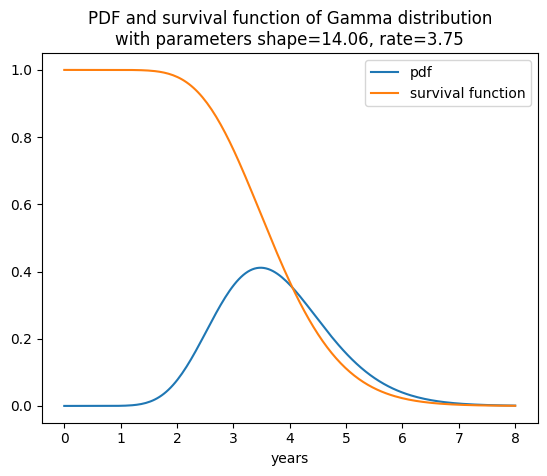

In [52]:
t = np.linspace(0, 8, 200)
plt.plot(t, gamma_dist.pdf(t), label='pdf')
plt.plot(t, gamma_dist.sf(t), label='survival function')
plt.xlabel('years')
plt.title(
    "PDF and survival function of Gamma distribution"
    f"\nwith parameters {shape=:.2f}, {rate=:.2f}")
plt.legend()
plt.show()

# Define hazard function and draw plot

With the above Gamma distribution and a time step of 6 months, basically all of the transitions to MCI will occur at exactly 3.5 or 4 years after becoming presymptomatic.

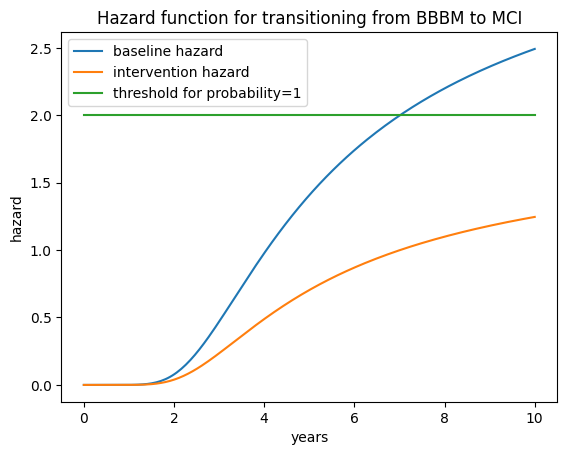

In [55]:
def hazard(t, dist):
    # hazard = (probability density) / (survival function)
    return dist.pdf(t) / dist.sf(t)

def hazard_with_logs(t, dist):
    # Take logs first to avoid underflow
    return np.exp(dist.logpdf(t) - dist.logsf(t))

gamma_hazard = lambda t: hazard(t, gamma_dist)

t = np.linspace(0, 10, 200)
plt.plot(t, gamma_hazard(t), label='baseline hazard')
# Client specified hazard ratio between 0.4 and 0.6
hazard_ratio = 0.5
# Plot new hazard function in intervention scenario
plt.plot(t, hazard_ratio * gamma_hazard(t), label='intervention hazard')

# Since our timestep is dt = 0.5 years, and we multiply hazard by timestep
# to get probability, as soon as the hazard function crosses the line y = 2
# we will get probability equal to 1 of transitioning on that timestep
plt.plot(t, 2 * np.ones_like(t), label='threshold for probability=1')

plt.xlabel('years')
plt.ylabel('hazard')
plt.title("Hazard function for transitioning from BBBM to MCI")
plt.legend()
plt.show()

In [54]:
𝛼 = 4
𝛼

4

# Define a function to calculate incidence rate = person-time-average hazard over a time interval

In [65]:
def incidence_rate(dist, t0, t1, args=(), **kwargs):
    population_decrease = dist.sf(t0) - dist.sf(t1)
    integration_results = scipy.integrate.quad(dist.sf, t0, t1, args, **kwargs)
    person_time = integration_results[0]
    return population_decrease / person_time, integration_results

# Looks like 27% annual progression rate over the first 10 years
incidence_rate(gamma_dist, 0, 10, full_output=0)

(np.float64(0.2666657441293802), (3.7499984749021316, 9.423166011981954e-13))

# Now try a Weibull distribution

Abie specified this calibrated this to match the Client's request for progression probability of 50% at 5 years and 80% at 10 years.

And he says it should average out to about 15% annual progression, too.

In [86]:
λ=6.76
k=1.22

weibull_dist = scipy.stats.weibull_min(k, scale=λ)
weibull_dist.cdf([5, 10])

array([0.49950771, 0.8005858 ])

In [87]:
# Looks like incidence rate over first 10 years is about 14.8%/year
incidence_rate(weibull_dist, 0, 10, full_output=0)

(np.float64(0.1484783792635485), (5.3919351824889885, 7.339163322605487e-08))

In [88]:
1 / 0.1484783792635485

6.734987308994019

In [89]:
weibull_dist.stats()

(np.float64(6.332450889735727), np.float64(27.213979738215155))

In [90]:
# The mean can be computed in terms of the gamma function
λ * scipy.special.gamma(1 + 1/k)

np.float64(6.332450889735727)

In [ ]:
# Overall incidence rate
1 / weibull_dist.mean()

np.float64(0.15791673988674756)

# Draw Weibull PDF and survival function


The survival function is

$$
S(t) = e^{-(t/\lambda)^k},
$$

and the probability density function is

$$
f(t) = \frac{k}{\lambda} \left(\frac{t}{\lambda}\right)^{k-1} e^{-(t/\lambda)^k}.
$$

It's pretty close to an exponential distribution since the shape parameter $k$ is close to 1.

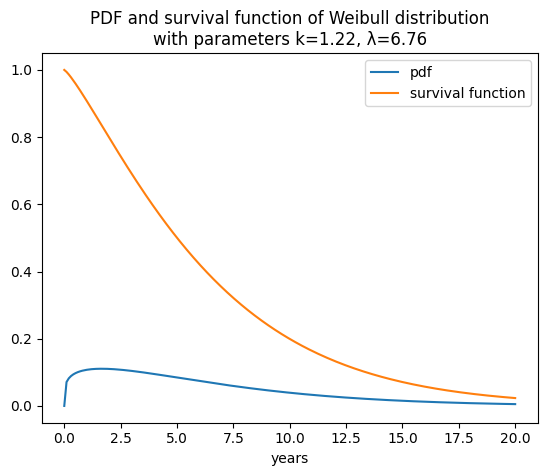

In [91]:
t = np.linspace(0, 20, 200)
plt.plot(t, weibull_dist.pdf(t), label='pdf')
plt.plot(t, weibull_dist.sf(t), label='survival function')
plt.xlabel('years')
plt.title(
    "PDF and survival function of Weibull distribution"
    f"\nwith parameters {k=:.2f}, {λ=:.2f}")
plt.legend()
plt.show()

# Draw hazard function for Weibull distribution

The hazard function is

$$
h(t) = \frac{k}{\lambda} \left(\frac{t}{\lambda}\right)^{k-1}.
$$

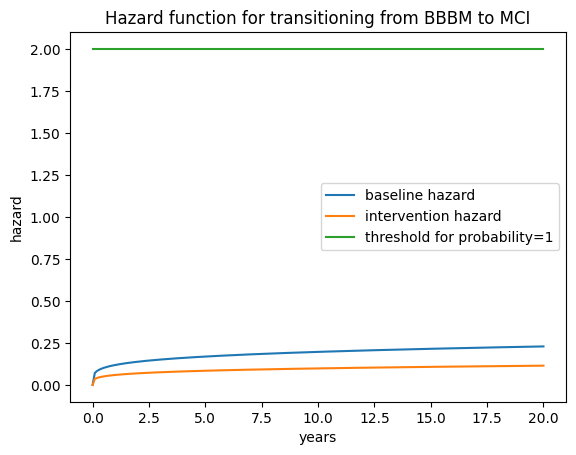

In [78]:
weibull_hazard = lambda t: hazard(t, weibull_dist)

t = np.linspace(0, 20, 200)
plt.plot(t, weibull_hazard(t), label='baseline hazard')
# Client specified hazard ratio between 0.4 and 0.6
hazard_ratio = 0.5
# Plot new hazard function in intervention scenario
plt.plot(t, hazard_ratio * weibull_hazard(t), label='intervention hazard')
# For Weibull distribution, the hazard function is a power function:
# plt.plot(t, (k/λ) * (t/λ) ** (k-1))

# Since our timestep is dt = 0.5 years, and we multiply hazard by timestep
# to get probability, as soon as the hazard function crosses the line y = 2
# we will get probability equal to 1 of transitioning on that timestep
plt.plot(t, 2 * np.ones_like(t), label='threshold for probability=1')

plt.xlabel('years')
plt.ylabel('hazard')
plt.title("Hazard function for transitioning from BBBM to MCI")
plt.legend()
plt.show()

In [93]:
weibull_dist.mean() + 3.85

np.float64(10.182450889735726)